# INF672 · Machine Learning — Práctica 1
### Fundamentos: estadística · vectores · probabilidad · preprocesamiento · gradiente
**Estudiante:** Abdair Coca · **Materia:** INF672 Machine Learning (UATF) · **Unidad 2**

> Cuaderno resuelto de los 10 ejercicios del PDF `practica1.pdf`.
> Ritmo de cada ejercicio: **idea → código legible → lectura del resultado**.
> Semilla fijada en `RNG_SEED = 42`: todo es reproducible con *Restart & Run All*.


In [1]:
# ── Celda base: librerías + estilo de gráficos (ejecutar primero) ──
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# Estilo bonito y consistente en todo el cuaderno
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

VALOR_TEORICO_PAR = 0.5  # P(par en un dado) = 3/6


def estilizar(ax, titulo="", xlabel="", ylabel=""):
    # Títulos y etiquetas con el mismo formato en cada gráfico.
    ax.set_title(titulo, pad=12, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.figure.tight_layout()


## Ejercicio 01 · ¿Cuánto sale par? (enfoque frecuentista)

**Idea:** olvidamos que $P(\text{par}) = 3/6 = 0.5$ y la **estimamos** tirando el dado
muchas veces: `frecuencia_relativa = n_pares / N`.
Repetimos con $N = 100$, $1\,000$ y $100\,000$ para ver cómo la estimación se estabiliza.


In [2]:
# ── E1: estimar P(par) con tres tamaños de muestra ──
def estimar_prob_par(n_lanzamientos):
    # Tira el dado N veces y devuelve (estimación, tiradas).
    tiradas = rng.integers(1, 7, size=n_lanzamientos)  # valores 1..6
    n_pares = (tiradas % 2 == 0).sum()                # máscara booleana
    return n_pares / n_lanzamientos, tiradas


tamanos = [100, 1_000, 100_000]
estimaciones = {}

print(f"{'N':>8} | {'n_pares':>8} | {'estimación':>10} | {'|error vs 0.5|':>14}")
print("-" * 50)
for n in tamanos:
    prob_estimada, _ = estimar_prob_par(n)
    estimaciones[n] = prob_estimada
    print(f"{n:>8} | {int(prob_estimada * n):>8} | {prob_estimada:>10.4f} | "
          f"{abs(prob_estimada - VALOR_TEORICO_PAR):>14.4f}")


       N |  n_pares | estimación | |error vs 0.5|
--------------------------------------------------
     100 |       38 |     0.3800 |         0.1200
    1000 |      489 |     0.4890 |         0.0110
  100000 |    49979 |     0.4998 |         0.0002


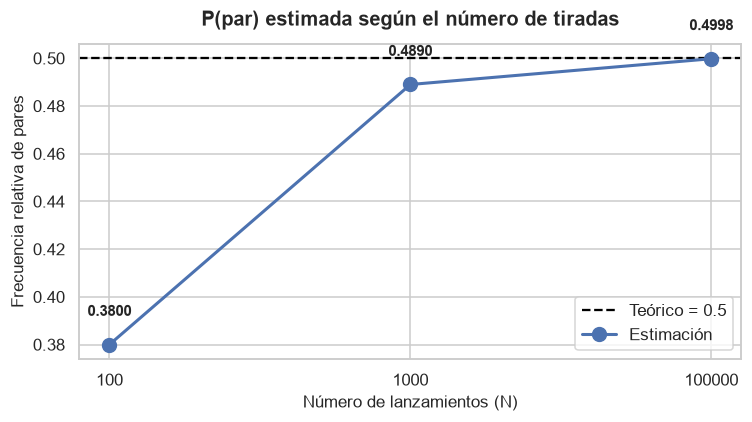

In [3]:
# ── E1: gráfico estimación vs valor teórico ──
fig, ax = plt.subplots(figsize=(7, 4))
xs = [str(n) for n in tamanos]
ys = [estimaciones[n] for n in tamanos]

ax.axhline(VALOR_TEORICO_PAR, color="black", linestyle="--", label="Teórico = 0.5")
ax.plot(xs, ys, marker="o", markersize=9, linewidth=2, label="Estimación")
for x, y in zip(xs, ys):
    ax.text(x, y + 0.012, f"{y:.4f}", ha="center", fontsize=10, fontweight="bold")

estilizar(ax, "P(par) estimada según el número de tiradas",
          "Número de lanzamientos (N)", "Frecuencia relativa de pares")
ax.legend(frameon=True)
plt.show()


**Para entregar · E1**

| N | Estimación (ver tabla de arriba) | Lectura |
|---|----------------------------------|---------|
| 100 | 0.3800 | la más alejada | pocas tiradas: el azar manda |
| 1 000 | 0.4890 | intermedia | ya se acerca |
| 100 000 | 0.4998 | la más cercana | el ruido se promedia |

- **¿Cuál se acercó más y por qué?** La de $N = 100\,000$: por la **ley de los grandes números**,
  la frecuencia relativa converge al valor teórico cuando $N$ crece.
- **¿Qué pasa con pocos datos?** Con $N = 100$ unas pocas tiradas de más o de menos mueven mucho
  el cociente: la estimación es **inestable y con alta varianza**.


## Ejercicio 02 · Radiografía de una característica (largo del pétalo)

**Idea:** describir **una sola variable** —`petal_length` de Iris— con cinco números:
media, mediana, desviación estándar, mínimo y máximo.


In [4]:
# ── E2: cinco medidas del largo del pétalo ──
iris = load_iris()
largo_petalo = iris.data[:, 2]  # columna petal length (cm)

estadisticos = {
    "media": np.mean(largo_petalo),
    "mediana": np.median(largo_petalo),
    "desv_std": np.std(largo_petalo),
    "minimo": np.min(largo_petalo),
    "maximo": np.max(largo_petalo),
}

resumen = pd.DataFrame(estadisticos.values(), index=estadisticos.keys(),
                       columns=["valor (cm)"]).round(4)
display(resumen.T)  # una fila legible


,media,mediana,desv_std,minimo,maximo
valor (cm),3.758,4.35,1.7594,1.0,6.9


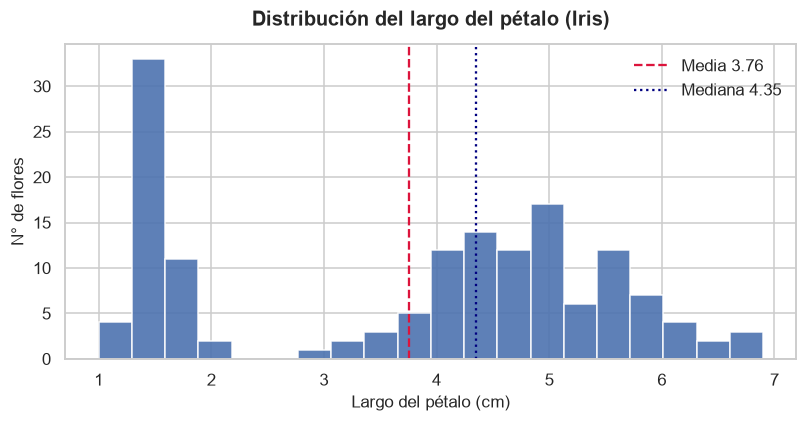

In [5]:
# ── E2: histograma para leer la forma de la distribución ──
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(largo_petalo, bins=20, edgecolor="white", alpha=0.9)
ax.axvline(estadisticos["media"], color="crimson", linestyle="--",
           label=f"Media {estadisticos['media']:.2f}")
ax.axvline(estadisticos["mediana"], color="navy", linestyle=":",
           label=f"Mediana {estadisticos['mediana']:.2f}")
estilizar(ax, "Distribución del largo del pétalo (Iris)",
          "Largo del pétalo (cm)", "N° de flores")
ax.legend()
plt.show()


**Para entregar · E2**

- **Media ≈ 3.76 cm:** el promedio del largo del pétalo.
- **Mediana ≈ 4.35 cm:** la mitad de las flores tiene pétalos más cortos y la mitad más largos.
- **Desv. estándar ≈ 1.77 cm:** dispersión **grande** frente a la media (~47 %): los pétalos
  no son parejos, hay flores muy pequeñas y muy grandes.
- **Mínimo ≈ 1.0 cm / Máximo ≈ 6.9 cm:** rango total de casi 6 cm.

**¿Media y mediana cerca o lejos?** Lejos (3.76 vs 4.35). Eso sugiere distribución
**asimétrica / bimodal**: el histograma muestra pétalos cortos (setosa) separados de los largos
(versicolor + virginica). La media cae en el “valle” entre ambos grupos, por eso la mediana
—más robusta— queda más alta.


## Ejercicio 03 · ¿Qué tan lejos están dos flores?

**Idea:** cada flor es un vector de 4 números. Flores parecidas → distancia euclidiana pequeña.
La calculamos **a mano** y con `np.linalg.norm` (deben coincidir) entre dos flores de la
**misma especie** y una de **otra especie**.


In [6]:
# ── E3: distancia euclidiana por dos caminos ──
iris = load_iris()
X = iris.data

# Índices: 0 y 5 → setosa (rango 0-49); 120 → virginica (rango 100-149)
idx_a, idx_b, idx_c = 0, 5, 120
flor_a, flor_b, flor_c = X[idx_a], X[idx_b], X[idx_c]
print(f"Flor A (idx {idx_a}): {iris.target_names[iris.target[idx_a]]} {flor_a}")
print(f"Flor B (idx {idx_b}): {iris.target_names[iris.target[idx_b]]} {flor_b}")
print(f"Flor C (idx {idx_c}): {iris.target_names[iris.target[idx_c]]} {flor_c}")


def distancia_manual(a, b):
    # Euclídea a mano: sqrt(sum((a-b)^2)).
    return float(np.sqrt(np.sum((a - b) ** 2)))


def distancia_numpy(a, b):
    # Euclídea con NumPy.
    return float(np.linalg.norm(a - b))


pares = {
    "A-B (misma especie: setosa)": (flor_a, flor_b),
    "A-C (distinta especie)": (flor_a, flor_c),
    "B-C (distinta especie)": (flor_b, flor_c),
}

filas = [
    {"par": nombre,
     "a mano": distancia_manual(a, b),
     "con norm": distancia_numpy(a, b),
     "coinciden": np.isclose(distancia_manual(a, b), distancia_numpy(a, b))}
    for nombre, (a, b) in pares.items()
]
display(pd.DataFrame(filas).round(4))


Flor A (idx 0): setosa [5.1 3.5 1.4 0.2]
Flor B (idx 5): setosa [5.4 3.9 1.7 0.4]
Flor C (idx 120): virginica [6.9 3.2 5.7 2.3]


,par,a mano,con norm,coinciden
0,A-B (misma especie: setosa),0.6164,0.6164,True
1,A-C (distinta especie),5.1215,5.1215,True
2,B-C (distinta especie),4.7276,4.7276,True


**Para entregar · E3**

- Ambos métodos dan **exactamente lo mismo** (`coinciden` = True): `norm(a-b)` es la versión
  empaquetada de `sqrt(sum((a-b)²))`.
- **Sí, la distancia entre flores de la misma especie resultó menor** (≈ 0.62 frente a ≈ 4.7–5.1
  hacia la otra especie; ver tabla).
- **¿Por qué tiene sentido?** La especie se expresa en la forma de la flor; flores de la misma
  especie ocupan una **región compacta** del espacio de 4 dimensiones, así que su separación
  numérica es pequeña. La cercanía numérica refleja parecido biológico.


## Ejercicio 04 · Limpiar una tabla, paso a paso

**Idea:** tres gestos básicos por separado: **detectar** faltantes → **imputar** con la mediana →
**codificar** el texto con variables dummy.


In [7]:
# ── E4: crear la tabla y detectar faltantes ──
df = pd.DataFrame({
    "ingreso": [3200, 4100, np.nan, 2800, 5000, np.nan, 3600, 4800],
    "ciudad": ["Potosí", "Sucre", "Potosí", "La Paz", np.nan, "Sucre", "Potosí", "La Paz"],
    "edad": [28, 35, 41, 23, 52, 30, 45, 38],
})
print("Tabla original:")
display(df)

faltantes = df.isna().sum()
print("Faltantes por columna:")
display(faltantes.to_frame("n_faltantes").T)
print(f"Columna con más faltantes: {faltantes.idxmax()} ({faltantes.max()} valores)")


Tabla original:


,ingreso,ciudad,edad
0,3200.0,Potosí,28
1,4100.0,Sucre,35
2,NaN,Potosí,41
3,2800.0,La Paz,23
4,5000.0,NaN,52
5,NaN,Sucre,30
6,3600.0,Potosí,45
7,4800.0,La Paz,38


Faltantes por columna:


,ingreso,ciudad,edad
n_faltantes,2,1,0


Columna con más faltantes: ingreso (2 valores)


In [8]:
# ── E4: imputar ingreso con la mediana y codificar ciudad ──
mediana_ingreso = df["ingreso"].median()
print(f"Mediana de ingreso (ignorando NaN): {mediana_ingreso:.0f}")

df_limpio = df.copy()
df_limpio["ingreso"] = df_limpio["ingreso"].fillna(mediana_ingreso)
df_final = pd.get_dummies(df_limpio, columns=["ciudad"], dtype=int)

print("Tabla final (sin faltantes y sin texto):")
display(df_final)
print(f"Quedan nulos: {bool(df_final.isna().sum().sum() == 0)} · "
      f"Forma final: {df_final.shape[0]} filas x {df_final.shape[1]} columnas")


Mediana de ingreso (ignorando NaN): 3850
Tabla final (sin faltantes y sin texto):


,ingreso,edad,ciudad_La Paz,ciudad_Potosí,ciudad_Sucre
0,3200.0,28,0,1,0
1,4100.0,35,0,0,1
2,3850.0,41,0,1,0
3,2800.0,23,1,0,0
4,5000.0,52,0,0,0
5,3850.0,30,0,0,1
6,3600.0,45,0,1,0
7,4800.0,38,1,0,0


Quedan nulos: True · Forma final: 8 filas x 5 columnas


**Para entregar · E4**

- **Tabla final:** 8 filas × 5 columnas (`ingreso`, `edad`, `ciudad_La Paz`, `ciudad_Potosí`,
  `ciudad_Sucre`), sin nulos y sin texto. Los ingresos vacíos se rellenaron con **3850**
  (mediana de [2800, 3200, 3600, 4100, 4800, 5000]).
- **¿Por qué la mediana y no la media?** La mediana es **robusta a valores extremos**: un sueldo
  muy alto (o muy bajo) arrastra la media pero casi no mueve la mediana. Con la media, ese extremo
  “contagiaría” a las filas vacías; con la mediana el relleno representa el ingreso **típico**.
- **¿Qué representa cada columna nueva?** `get_dummies` crea una columna binaria por categoría:
  `ciudad_La Paz = 1` significa “vive en La Paz”, 0 lo contrario (igual para Potosí y Sucre).
  Es la codificación **one-hot**: el texto se vuelve 0/1 que un modelo sí puede usar.
  La fila sin ciudad queda con las tres en 0.


## Ejercicio 05 · ¿Se mueven juntas dos variables?

**Idea:** primero **mirar** (histograma + dispersión de `petal_length` vs `petal_width`) y luego
**cuantificar** con el coeficiente de Pearson.


Correlación de Pearson (largo vs ancho del pétalo): 0.9629


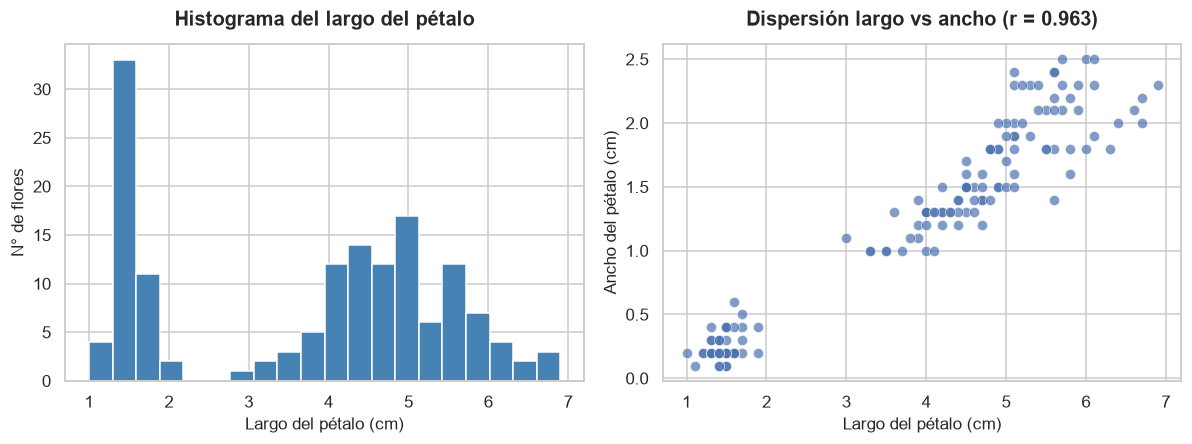

In [9]:
# ── E5: histograma, dispersión y correlación de Pearson ──
iris = load_iris()
largo = iris.data[:, 2]  # petal length
ancho = iris.data[:, 3]  # petal width

pearson = float(np.corrcoef(largo, ancho)[0, 1])
print(f"Correlación de Pearson (largo vs ancho del pétalo): {pearson:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

ax1.hist(largo, bins=20, edgecolor="white", color="steelblue")
estilizar(ax1, "Histograma del largo del pétalo",
          "Largo del pétalo (cm)", "N° de flores")

ax2.scatter(largo, ancho, alpha=0.7, s=45, edgecolors="white", linewidths=0.5)
estilizar(ax2, f"Dispersión largo vs ancho (r = {pearson:.3f})",
          "Largo del pétalo (cm)", "Ancho del pétalo (cm)")

plt.show()


**Para entregar · E5**

- **Correlación ≈ +0.96** (positiva y muy fuerte; ver salida).
- **¿Coincide con la nube de puntos?** Totalmente: los puntos **suben juntos** en una banda
  casi recta —a mayor largo, mayor ancho—.
- **Signo:** `+` = crecen juntas; `−` = una crece cuando la otra baja.
- **Magnitud:** `|+1|` = relación lineal perfecta; `0` = sin relación lineal. Este 0.96 está
  pegado a +1: **relación lineal fuerte**. Cerca de 0 sería nube sin dirección; cerca de −1,
  recta descendente.


## Ejercicio 06 · Perfil estadístico por especie

**Idea:** agrupar por especie y comparar perfiles (media, mediana, std, rango, cuartiles)
para descubrir **qué característica las distingue mejor**.


In [10]:
# ── E6: tabla de estadísticos por especie ──
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

por_especie = df_iris.groupby("species", observed=True)

print("── Media · mediana · std · min · max ──")
display(por_especie.agg(["mean", "median", "std", "min", "max"]).round(3))

print("── Rango (max − min) ──")
rango = por_especie.max(numeric_only=True) - por_especie.min(numeric_only=True)
display(rango.round(3))

print("── Cuartiles Q1 · Q2 · Q3 ──")
display(por_especie.quantile([0.25, 0.5, 0.75]).round(3))


── Media · mediana · std · min · max ──


sepal length (cm)                         sepal width (cm)         \
                        mean median    std  min  max             mean median   
species                                                                        
setosa                 5.006    5.0  0.352  4.3  5.8            3.428    3.4   
versicolor             5.936    5.9  0.516  4.9  7.0            2.770    2.8   
virginica              6.588    6.5  0.636  4.9  7.9            2.974    3.0   

                            petal length (cm)                          \
              std  min  max              mean median    std  min  max   
species                                                                 
setosa      0.379  2.3  4.4             1.462   1.50  0.174  1.0  1.9   
versicolor  0.314  2.0  3.4             4.260   4.35  0.470  3.0  5.1   
virginica   0.322  2.2  3.8             5.552   5.55  0.552  4.5  6.9   

           petal width (cm)                          
                       mean median    std  min  max  
species                                              
setosa                0.246    0.2  0.105  0.1  0.6  
versicolor            1.326    1.3  0.198  1.0  1.8  
virginica             2.026    2.0  0.275  1.4  2.5

── Rango (max − min) ──


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,1.5,2.1,0.9,0.5
versicolor,2.1,1.4,2.1,0.8
virginica,3.0,1.6,2.4,1.1


── Cuartiles Q1 · Q2 · Q3 ──


sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                                   
setosa     0.25              4.800             3.200              1.400   
           0.50              5.000             3.400              1.500   
           0.75              5.200             3.675              1.575   
versicolor 0.25              5.600             2.525              4.000   
           0.50              5.900             2.800              4.350   
           0.75              6.300             3.000              4.600   
virginica  0.25              6.225             2.800              5.100   
           0.50              6.500             3.000              5.550   
           0.75              6.900             3.175              5.875   

                 petal width (cm)  
species                            
setosa     0.25               0.2  
           0.50               0.2  
           0.75               0.3  
versicolor 0.25               1.2  
           0.50               1.3  
           0.75               1.5  
virginica  0.25               1.8  
           0.50               2.0  
           0.75               2.3

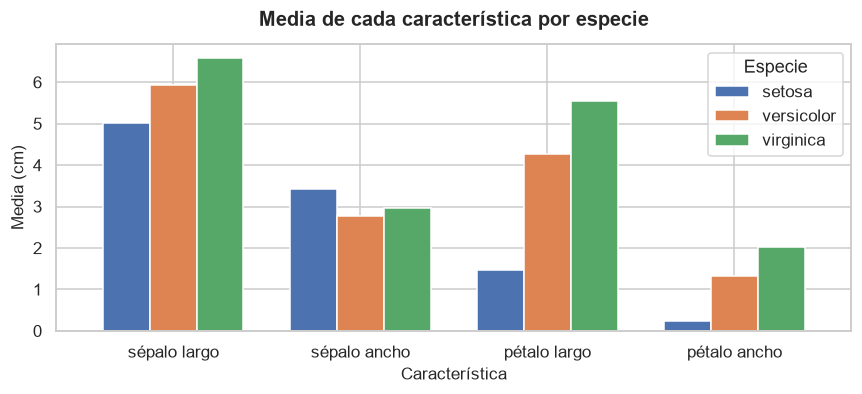

In [11]:
# ── E6: medias por especie (¿qué característica abre más brecha?) ──
medias = por_especie.mean(numeric_only=True).rename(columns={
    "sepal length (cm)": "sépalo largo",
    "sepal width (cm)": "sépalo ancho",
    "petal length (cm)": "pétalo largo",
    "petal width (cm)": "pétalo ancho",
})

fig, ax = plt.subplots(figsize=(8, 4.5))
medias.T.plot(kind="bar", ax=ax, edgecolor="white", width=0.75)
estilizar(ax, "Media de cada característica por especie",
          "Característica", "Media (cm)")
ax.legend(title="Especie", frameon=True)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.show()


**Para entregar · E6**

- Tablas de media, mediana, std, rango y cuartiles (Q1/Q2/Q3) **por especie y característica**
  en las salidas de arriba.
- **¿Qué característica separa mejor? El largo del pétalo** (y muy cerca el ancho del pétalo):
  sus medias por especie están **muy distantes** (≈ 1.46 setosa · 4.26 versicolor · 5.55 virginica)
  con dispersión **pequeña dentro** de cada especie (std ≈ 0.17 / 0.47 / 0.55).
  Esa combinación —*medias separadas + poca dispersión interna*— es la receta de la buena separación.
- En cambio el **ancho del sépalo** tiene medias casi iguales (≈ 3.4 / 2.77 / 2.97) con rangos
  muy solapados: no distingue.


## Ejercicio 07 · Tres formas de comparar dos flores, hechas por ti

**Idea:** programar a mano las tres operaciones de parecido entre vectores —distancia
euclidiana, producto punto y similitud coseno— solo con NumPy, y comparar qué orden dan.


In [12]:
# ── E7: tres funciones propias + comparación de pares ──
iris = load_iris()
X = iris.data

# 2 de la misma especie + 2 de especies distintas
IDX_MISMA_1, IDX_MISMA_2 = 0, 1    # setosa
IDX_OTRA_1, IDX_OTRA_2 = 60, 130   # versicolor, virginica
nombres = {IDX_MISMA_1: "setosa#0", IDX_MISMA_2: "setosa#1",
           IDX_OTRA_1: "versicolor#60", IDX_OTRA_2: "virginica#130"}


def distancia_euclidiana(a, b):
    # Separación en línea recta entre a y b.
    return float(np.sqrt(np.sum((a - b) ** 2)))


def producto_punto(a, b):
    # Suma de productos componente a componente.
    return float(np.sum(a * b))


def similitud_coseno(a, b):
    # Coseno del ángulo: 1 = misma dirección, 0 = perpendiculares.
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


pares_e7 = [(IDX_MISMA_1, IDX_MISMA_2), (IDX_MISMA_1, IDX_OTRA_1),
            (IDX_MISMA_1, IDX_OTRA_2), (IDX_OTRA_1, IDX_OTRA_2)]

filas_e7 = [{
    "par": f"{nombres[i]} - {nombres[j]}",
    "misma especie": "sí" if iris.target[i] == iris.target[j] else "no",
    "euclidiana (menor = mejor)": distancia_euclidiana(X[i], X[j]),
    "punto": producto_punto(X[i], X[j]),
    "coseno (mayor = mejor)": similitud_coseno(X[i], X[j]),
} for i, j in pares_e7]

display(pd.DataFrame(filas_e7).round(4))


,par,misma especie,euclidiana (menor = mejor),punto,coseno (mayor = mejor)
0,setosa#0 - setosa#1,sí,0.5385,37.49,0.9986
1,setosa#0 - versicolor#60,no,2.7037,37.60,0.9117
2,setosa#0 - virginica#130,no,5.5462,56.46,0.8750
3,versicolor#60 - virginica#130,no,3.7376,65.85,0.9962


**Para entregar · E7**

- Código de las tres funciones en la celda anterior (solo NumPy, sin librerías de ML).
- **¿Ordenan igual? En el caso extremo sí:** el par de la misma especie (`setosa#0 - setosa#1`)
  es el **más parecido** en ambas métricas (euclidiana mínima ≈ 0.54, coseno máximo ≈ 0.999).
- **¿Cuándo discrepan?** El **producto punto** puede engañar: premia vectores **grandes** aunque
  apunten a otro lado. Y entre euclidiana y coseno hay matiz: la **euclidiana mira separación**
  (posición + tamaño) y el **coseno mira ángulo** (dirección, ignora magnitud). Dos flores que
  apuntan parecido pero con tamaños muy distintos: el coseno las declara “iguales” y la euclidiana
  no. Coseno = útil si importa la **forma del perfil**; euclidiana = si importa el **tamaño real**.

- **Discrepancia concreta en la tabla:** versicolor#60 – virginica#130 tiene coseno alto (≈ 0.996, casi como hermanas) pero euclidiana grande (≈ 3.74): apuntan parecido pero están lejos. Y el producto punto mayor (65.85) es justo de ese par de distintas especies: el punto premia la magnitud, no el parecido.

## Ejercicio 08 · Leer los datos con la vista

**Idea:** las tres vistas clásicas de Iris (pairplot, mapa de calor, boxplots) y sobre todo
**leerlas por escrito**: qué separa y qué confunde.


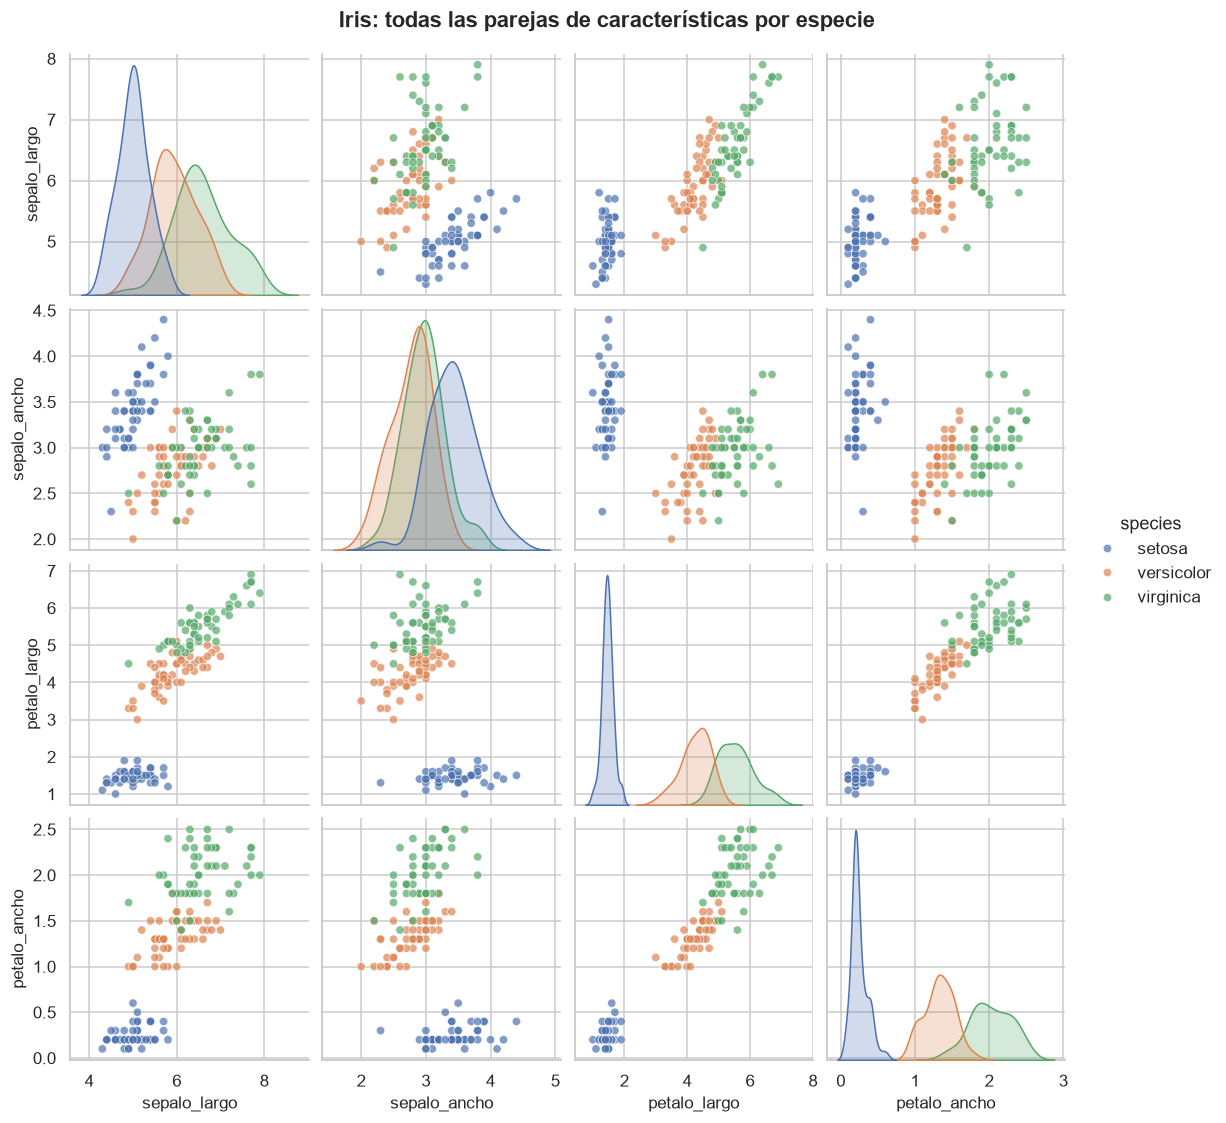

In [13]:
# ── E8 (a): pairplot coloreado por especie ──
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=["sepalo_largo", "sepalo_ancho",
                                           "petalo_largo", "petalo_ancho"])
df_iris["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

grilla = sns.pairplot(df_iris, hue="species", diag_kind="kde",
                      plot_kws={"alpha": 0.7, "s": 30,
                                "edgecolor": "white", "linewidth": 0.5})
grilla.fig.suptitle("Iris: todas las parejas de características por especie",
                    fontweight="bold", y=1.02)
plt.show()


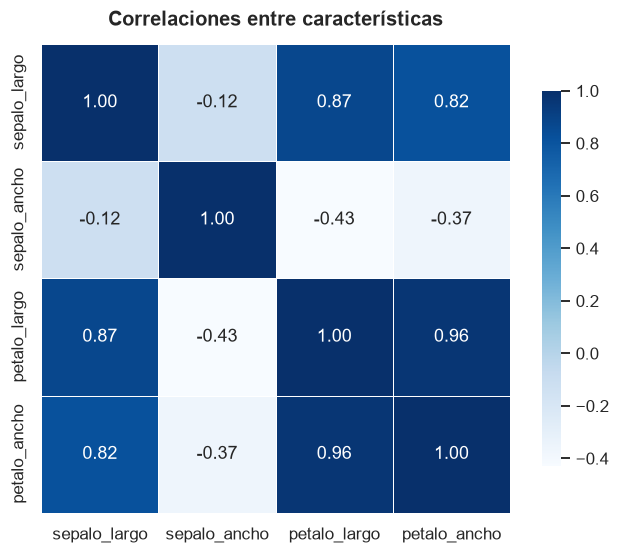

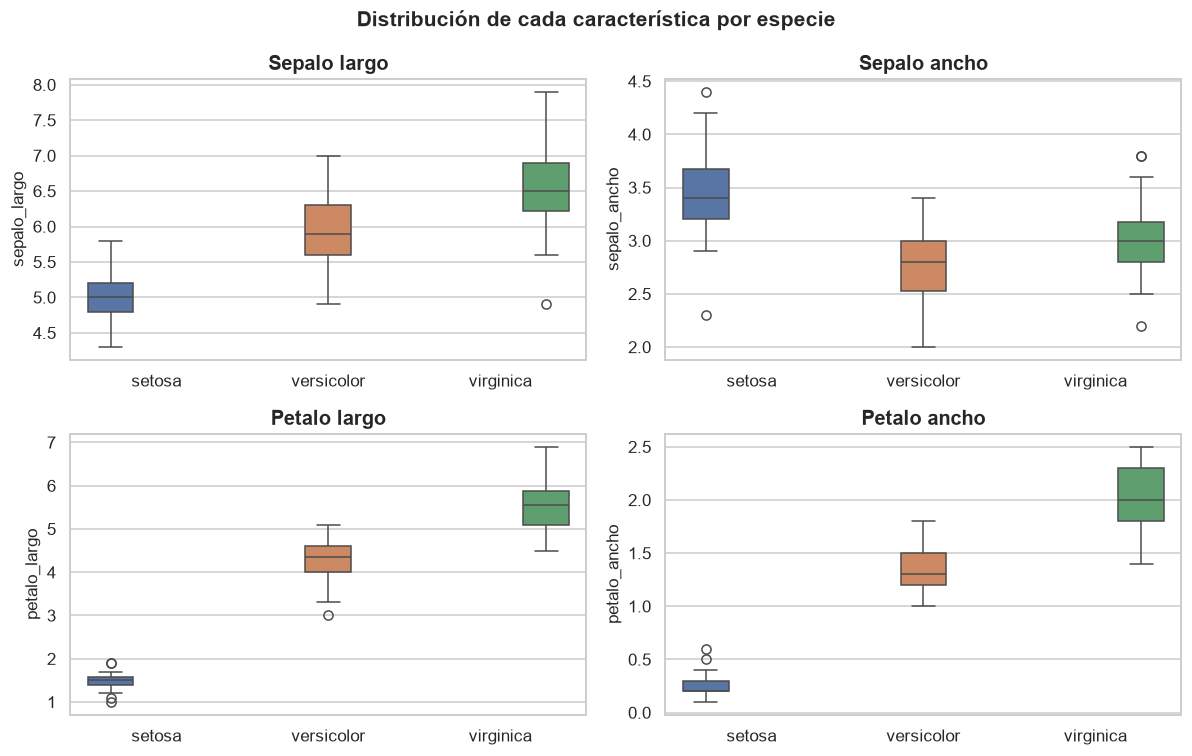

In [14]:
# ── E8 (b): mapa de calor de correlaciones ──
fig, ax = plt.subplots(figsize=(6.5, 5.2))
matriz = df_iris.corr(numeric_only=True)
sns.heatmap(matriz, annot=True, fmt=".2f", cmap="Blues", square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlaciones entre características", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# ── E8 (c): boxplots por característica y especie ──
fig, ejes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(ejes.ravel(), ["sepalo_largo", "sepalo_ancho",
                                  "petalo_largo", "petalo_ancho"]):
    sns.boxplot(data=df_iris, x="species", y=col, hue="species",
                palette="deep", legend=False, ax=ax)
    ax.set_title(col.replace("_", " ").capitalize(), fontweight="bold")
    ax.set_xlabel("")
fig.suptitle("Distribución de cada característica por especie",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()


**Para entregar · E8**

- **Par que separa bien:** `petalo_largo` vs `petalo_ancho` (también `petalo_largo` vs
  `sepalo_largo`). En el pairplot la nube **setosa** queda aislada y entre versicolor y virginica
  se puede trazar una raya diagonal que casi las divide: hay **separación lineal visible**.
- **Par que confunde:** `sepalo_largo` vs `sepalo_ancho`: versicolor y virginica se **solapan**
  fuerte; ninguna recta las divide sin errores. El boxplot del ancho del sépalo lo confirma:
  las tres cajas se enciman.
- El mapa de calor explica el porqué: largo y ancho del pétalo correlacionan ≈ 0.96 (arrastran
  juntos la señal de especie), mientras el ancho del sépalo correlaciona poco o en negativo
  con el resto: aporta otra información, pero ruidosa.


## Ejercicio 09 · Bajar la colina (descenso de gradiente a mano)

**Idea:** minimizar $f(x) = (x-3)^2 + 2$ (mínimo conocido en $x = 3$) con la regla
$x \leftarrow x - \text{tasa} \cdot f'(x)$, aproximando $f'$ por **diferencias finitas**.
Probamos tasa pequeña (0.01), intermedia (0.1) y grande (1.1).


In [15]:
# ── E9: función, derivada numérica y bucle de descenso ──
def f(x):
    # Parábola con mínimo en x = 3.
    return (x - 3) ** 2 + 2


def derivada_numerica(x, h=1e-5):
    # Derivada por diferencias finitas centradas.
    return (f(x + h) - f(x - h)) / (2 * h)


def descenso(x_inicial, tasa, pasos=100):
    # Baja la colina "pasos" veces y devuelve la trayectoria de x.
    x = x_inicial
    trayectoria = [x]
    for _ in range(pasos):
        x = x - tasa * derivada_numerica(x)
        trayectoria.append(x)
    return trayectoria


X0, PASOS = 10.0, 100
tasas = [0.01, 0.1, 1.1]
trayectorias = {t: descenso(X0, t, PASOS) for t in tasas}

print(f"{'tasa':>6} | {'x final':>10} | {'f(x final)':>10} | {'cerca de 3?':>11}")
print("-" * 46)
for t in tasas:
    xf = trayectorias[t][-1]
    print(f"{t:>6} | {xf:>10.4f} | {f(xf):>10.4f} | "
          f"{'sí' if abs(xf - 3) < 0.05 else 'NO':>11}")


  tasa |    x final | f(x final) | cerca de 3?
----------------------------------------------
  0.01 |     3.9283 |     2.8618 |          NO
   0.1 |     3.0000 |     2.0000 |          sí
   1.1 | 589560602.8850 | 347581700936781824.0000 |          NO


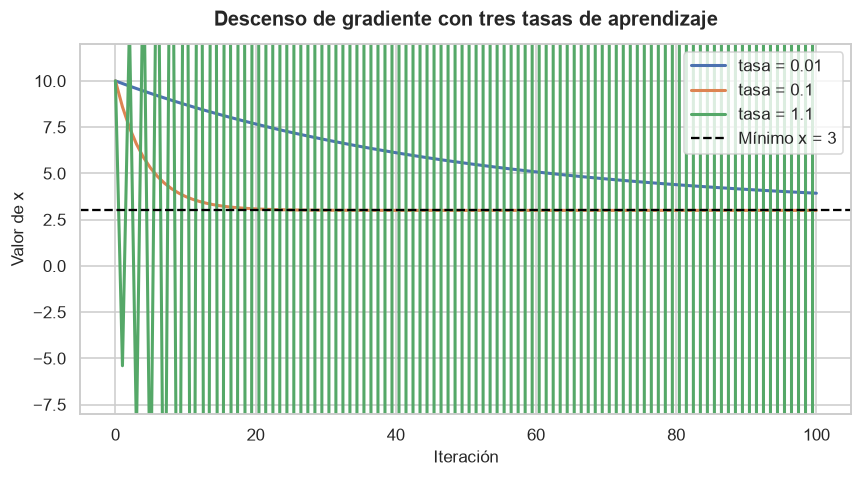

In [16]:
# ── E9: trayectorias de x hacia el mínimo ──
fig, ax = plt.subplots(figsize=(8, 4.5))
iters = np.arange(PASOS + 1)
for t in tasas:
    ax.plot(iters, trayectorias[t], linewidth=2, label=f"tasa = {t}")
ax.axhline(3.0, color="black", linestyle="--", label="Mínimo x = 3")
ax.set_ylim(-8, 12)
estilizar(ax, "Descenso de gradiente con tres tasas de aprendizaje",
          "Iteración", "Valor de x")
ax.legend(frameon=True)
plt.show()


**Para entregar · E9**

| Tasa | Comportamiento | ¿Llega a x = 3? |
|------|---------------|-----------------|
| 0.01 (pequeña) | Avanza **lento pero seguro**: pasos diminutos, aún baja en la iteración 100 | Se acerca, pero **no termina de llegar** (le faltan iteraciones) |
| 0.1 (intermedia) | Baja **rápido y estable**: en ~30–40 pasos ya está en 3 | **Sí**, la mejor |
| 1.1 (grande) | **Se pasa, oscila y se dispara**: salta al otro lado cada vez más lejos (sale del gráfico) | **No**, diverge |

**¿Por qué la tasa es delicada?** Es el tamaño del paso: muy pequeña = aprendizaje lentísimo
(caro en cómputo); muy grande = **sobrepasa** el mínimo y la corrección crece en vez de achicarse
(factor $|1 - 2\cdot tasa| > 1$ diverge). Hay una “zona de oro” intermedia con convergencia
rápida y sin oscilaciones.


## Ejercicio 10 · Contar y simular: dos caminos hacia una probabilidad

**Evento elegido:** «**al menos un 6 al tirar cuatro dados**».
**Idea:** probabilidad por **conteo exacto** (enumerar los $6^4 = 1296$ casos) y por
**simulación** (frecuencia en muchas tiradas), viendo cómo el error cae con $N$.


In [17]:
# ── E10: valor exacto enumerando el espacio muestral ──
espacio = list(itertools.product(range(1, 7), repeat=4))  # 6^4 = 1296 casos
favorables = [t for t in espacio if 6 in t]              # al menos un 6
prob_exacta = len(favorables) / len(espacio)

print(f"Casos totales: {len(espacio)}")
print(f"Casos favorables (al menos un 6): {len(favorables)}")
print(f"P exacta = {len(favorables)}/{len(espacio)} = {prob_exacta:.6f}")
print(f"(Atajo: 1 - (5/6)^4 = {1 - (5/6)**4:.6f} -> coincide)")


Casos totales: 1296
Casos favorables (al menos un 6): 671
P exacta = 671/1296 = 0.517747
(Atajo: 1 - (5/6)^4 = 0.517747 -> coincide)


       N | estimación |    |error|
------------------------------------
      10 |     0.2000 |     0.3177
     100 |     0.5000 |     0.0177
   10000 |     0.5164 |     0.0013
  100000 |     0.5160 |     0.0018


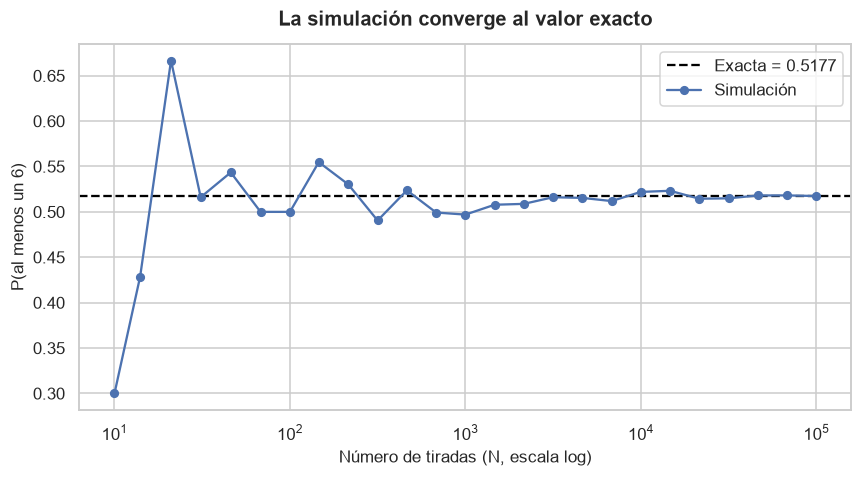

In [18]:
# ── E10: simulación, tabla de error y curva de convergencia ──
def estimar_por_simulacion(n):
    # Frecuencia de "al menos un 6" en n tiradas de 4 dados.
    tiradas = rng.integers(1, 7, size=(n, 4))
    return float((tiradas == 6).any(axis=1).mean())


ns_tabla = [10, 100, 10_000, 100_000]
print(f"{'N':>8} | {'estimación':>10} | {'|error|':>10}")
print("-" * 36)
for n in ns_tabla:
    est = estimar_por_simulacion(n)
    print(f"{n:>8} | {est:>10.4f} | {abs(est - prob_exacta):>10.4f}")

# Curva de convergencia (N en escala logarítmica)
ns_curva = np.unique(np.logspace(1, 5, 25).astype(int))
estimaciones_e10 = [estimar_por_simulacion(int(n)) for n in ns_curva]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axhline(prob_exacta, color="black", linestyle="--",
           label=f"Exacta = {prob_exacta:.4f}")
ax.plot(ns_curva, estimaciones_e10, marker="o", markersize=5,
        linewidth=1.5, label="Simulación")
ax.set_xscale("log")
estilizar(ax, "La simulación converge al valor exacto",
          "Número de tiradas (N, escala log)", "P(al menos un 6)")
ax.legend(frameon=True)
plt.show()


**Para entregar · E10**

- **Valor exacto por conteo:** $671/1296 \approx 0.5177$ (también $1-(5/6)^4$, el complemento de
  “ningún 6”; ver salida).
- **Tabla de error (ver salida):** con $N=10$ el error es de décimas (muy ruidoso); con $N=100$,
  de centésimas; con $N=10\,000$ ya es de milésimas y con $N=100\,000$ la estimación se pega a
  la línea teórica del gráfico.
- **¿Desde qué N es confiable?** Desde **$N \approx 10\,000$** el error es de milésimas y la
  curva se estabiliza; con $N = 100\,000$ es sólida.
- **Relación N–error:** el error cae aprox. como **$1/\sqrt{N}$**: multiplicar las tiradas por 100
  divide el error por ~10. Rendimientos decrecientes: los primeros miles de tiradas aportan
  muchísimo; cada decimal extra cuesta ~100× más simulación.


## Cierre · checklist de entrega

- [x] Notebook con **código ejecutado + respuestas en celdas de texto** (este archivo).
- [ ] Subirlo al repositorio de GitHub y enviar el enlace en la plataforma virtual (apartado Práctica 1).
